
=== Demo pipeline ===
Input locations: ['Warehouse', 'C1', 'C2', 'C3']
Parcels: {'C1': {'value': 50, 'time': (9, 12), 'weight': 10}, 'C2': {'value': 60, 'time': (10, 13), 'weight': 20}, 'C3': {'value': 40, 'time': (11, 14), 'weight': 15}}
Capacity: 30

Greedy selected parcels: ['C1', 'C2']  value: 110  weight: 30
DP exact selection: ['C1', 'C2']  value: 110

TSP brute force route (selected customers): ['Warehouse', 'C1', 'C2', 'Warehouse']
TSP cost: 17


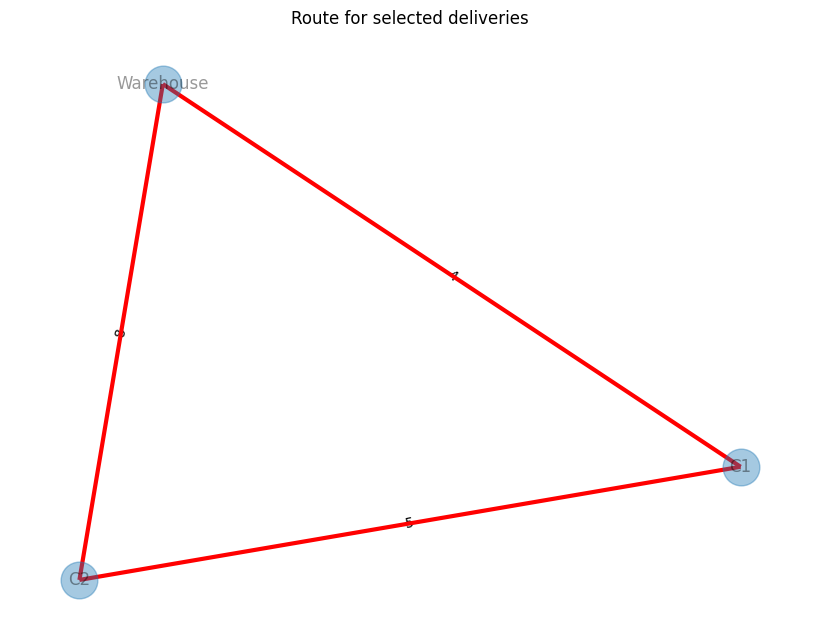

Time window feasible?: False  arrivals: {'C1': 12.0, 'C2': 17.0}

Dijkstra shortest path distances from Warehouse:
{'Warehouse': 0, 'C1': 4, 'C3': 6, 'C2': 8}
Prim MST total cost: 12
MST edges: [('Warehouse', 'C1', {'weight': 4}), ('C1', 'C2', {'weight': 5}), ('C2', 'C3', {'weight': 3})]


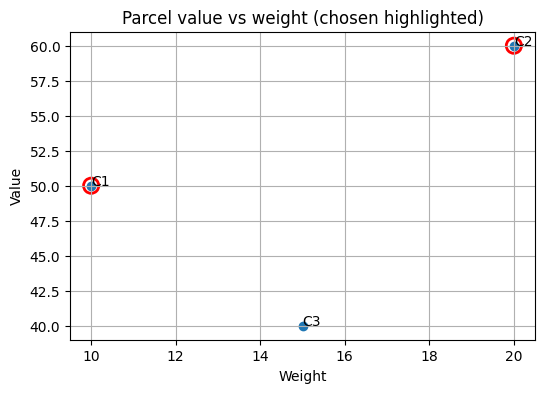


Held-Karp TSP (full locations):
Held-Karp route: ['Warehouse', 'C3', 'C2', 'C1', 'Warehouse']
Held-Karp cost: 18


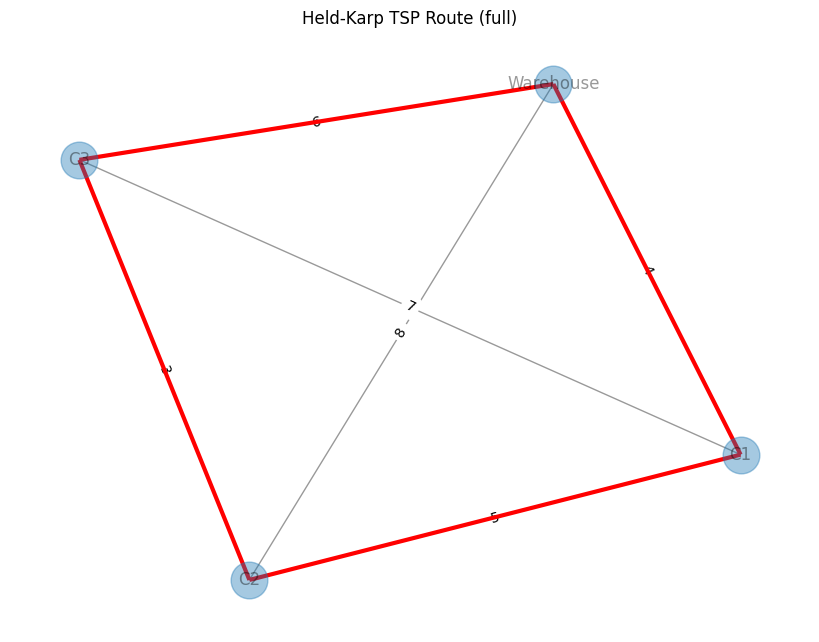


Profiling TSP brute force for n=3..7 (may be slow for >8)
n=3 (customers) avg runtime (brute) = 0.0000s
n=4 (customers) avg runtime (brute) = 0.0000s
n=5 (customers) avg runtime (brute) = 0.0001s
n=6 (customers) avg runtime (brute) = 0.0004s


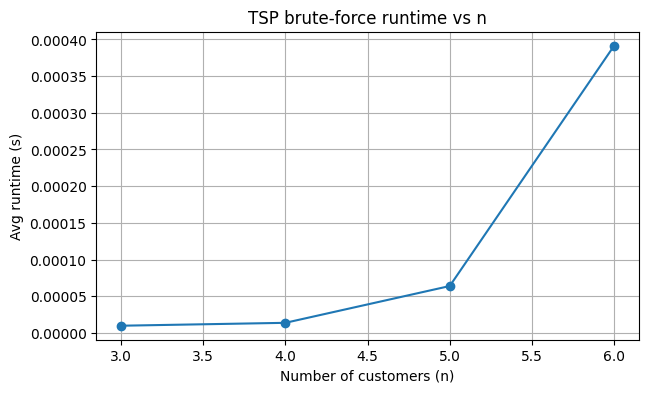

In [2]:


"""
delivery_route_optimization.py

Demonstrates:
 - Recurrence-based route cost (memoized)
 - Greedy parcel selection (value/weight)
 - Time-window feasibility checks
 - Dijkstra + Prim (networkx)
 - TSP: brute-force + Held-Karp DP
 - Visualizations: network route, profit-vs-weight
 - Profiling helpers for runtime vs n
"""

from itertools import permutations, combinations
from functools import lru_cache
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time

# ---------------------------
# Example Input Modeling
# ---------------------------
locations = ['Warehouse', 'C1', 'C2', 'C3']  # index 0 is warehouse
distance_matrix = [
    [0, 4, 8, 6],
    [4, 0, 5, 7],
    [8, 5, 0, 3],
    [6, 7, 3, 0]
]

parcels = {
    'C1': {'value': 50, 'time': (9, 12), 'weight': 10},
    'C2': {'value': 60, 'time': (10, 13), 'weight': 20},
    'C3': {'value': 40, 'time': (11, 14), 'weight': 15}
}

vehicle_capacity = 30  # weight capacity

# helper: map location -> index
loc_index = {loc: idx for idx, loc in enumerate(locations)}

# ---------------------------
# UNIT 1: Recurrence-based route cost estimation
#   - `delivery_cost(i, visited)` returns min cost from node i
#     to visit all unvisited nodes and return to warehouse (optional)
#   - Uses memoization
# ---------------------------
@lru_cache(maxsize=None)
def delivery_cost(idx, visited_mask):
    """
    idx: current node index
    visited_mask: bitmask of visited customer nodes (excludes warehouse bit 0)
    Convention: bit k corresponds to customer index k (1..n-1) at bit (k-1)
    Returns minimum additional distance to visit all remaining customers and return to warehouse.
    """
    n = len(locations)
    # all visited?
    all_mask = (1 << (n - 1)) - 1  # bits for customers
    if visited_mask == all_mask:
        # cost to return to warehouse
        return distance_matrix[idx][0]
    best = float('inf')
    # try next unvisited customer j
    for cust_idx in range(1, n):
        bit = 1 << (cust_idx - 1)
        if not (visited_mask & bit):
            cost_to_j = distance_matrix[idx][cust_idx]
            cost_rest = delivery_cost(cust_idx, visited_mask | bit)
            best = min(best, cost_to_j + cost_rest)
    return best

# Small wrapper to compute cost starting at warehouse with no visited
def recurrence_total_cost_returning():
    return delivery_cost(0, 0)


# ---------------------------
# UNIT 2: Greedy + DP selection
#   - Greedy 0/1 knapsack by value/weight
#   - A small exact DP knapsack included if you want exact selection
# ---------------------------
def greedy_select_parcels(parcels, capacity):
    items = []
    for loc, meta in parcels.items():
        items.append((loc, meta['value'], meta['weight'], meta['time']))
    # sort by value/weight descending
    items.sort(key=lambda x: x[1] / x[2], reverse=True)
    chosen = []
    total_weight = 0
    total_value = 0
    for loc, val, wt, t in items:
        if total_weight + wt <= capacity:
            chosen.append(loc)
            total_weight += wt
            total_value += val
    return chosen, total_value, total_weight

def dp_knapsack_exact(parcels, capacity):
    # classic DP over integer weights (weights small). Returns set of chosen location keys.
    items = list(parcels.items())  # [(loc, meta), ...]
    # convert to ints
    max_w = capacity
    n = len(items)
    dp = [[0]*(max_w+1) for _ in range(n+1)]
    choice = [[False]*(max_w+1) for _ in range(n+1)]
    for i in range(1, n+1):
        loc, meta = items[i-1]
        val = meta['value']
        wt = int(meta['weight'])
        for w in range(max_w+1):
            if wt <= w and dp[i-1][w-wt] + val > dp[i-1][w]:
                dp[i][w] = dp[i-1][w-wt] + val
                choice[i][w] = True
            else:
                dp[i][w] = dp[i-1][w]
    # recover
    w = max_w
    chosen = []
    for i in range(n, 0, -1):
        if choice[i][w]:
            loc, meta = items[i-1]
            chosen.append(loc)
            w -= int(meta['weight'])
    chosen.reverse()
    return chosen, dp[n][max_w]

# ---------------------------
# Time-window feasibility checker
#   - Given an ordered list of locations (route starting at warehouse),
#     compute arrival times and check if each arrival falls within time window
#   - Waiting allowed (arrive early and wait until earliest)
# ---------------------------
def check_time_windows(route, parcels, distance_matrix, locations):
    """
    route: list of locations in visiting order including Warehouse at start (and optionally at end)
    parcels: dict mapping customer -> meta with 'time': (earliest, latest)
    Returns (feasible, arrival_times) where arrival_times is dict loc->arrival_time
    Assumes start time at Warehouse is earliest needed (we set start_time = 8 by default)
    """
    # Use a start time baseline; real problem may set specific start time. Use 8am as example.
    time_now = 8.0
    arrival = {}
    for i in range(len(route)-1):
        cur = route[i]
        nxt = route[i+1]
        cur_idx = loc_index[cur]
        nxt_idx = loc_index[nxt]
        # travel
        time_now += distance_matrix[cur_idx][nxt_idx]
        arrival[nxt] = time_now
        # if nxt is a customer, enforce its earliest time (can wait)
        if nxt != 'Warehouse' and nxt in parcels:
            earliest, latest = parcels[nxt]['time']
            if time_now < earliest:
                time_now = earliest  # wait
                arrival[nxt] = time_now
            # if we arrive after latest, infeasible
            if arrival[nxt] > latest:
                return False, arrival
    return True, arrival

# Helper to get list indices for customers chosen
def route_from_permutation(perm_indices):
    # perm_indices are indices in locations excluding warehouse; return route starting at warehouse
    return [locations[0]] + [locations[i] for i in perm_indices] + [locations[0]]

# ---------------------------
# UNIT 3: Shortest Path (Dijkstra) and MST (Prim)
# ---------------------------
def build_graph_from_distance_matrix(locations, distance_matrix):
    G = nx.Graph()
    for i, u in enumerate(locations):
        G.add_node(u)
    n = len(locations)
    for i in range(n):
        for j in range(i+1, n):
            w = distance_matrix[i][j]
            G.add_edge(locations[i], locations[j], weight=w)
    return G

def dijkstra_single_source(locations, distance_matrix, source='Warehouse'):
    G = build_graph_from_distance_matrix(locations, distance_matrix)
    lengths = nx.single_source_dijkstra_path_length(G, source, weight='weight')
    return lengths

def prim_mst_total_cost(locations, distance_matrix):
    G = build_graph_from_distance_matrix(locations, distance_matrix)
    T = nx.minimum_spanning_tree(G, weight='weight')
    total = sum(d['weight'] for (u,v,d) in T.edges(data=True))
    edges = list(T.edges(data=True))
    return total, edges

# ---------------------------
# UNIT 4: TSP
#   - Brute-force via permutations
#   - Held-Karp DP (O(n^2 2^n)) for small n
# ---------------------------
def tsp_brute_force(locations, distance_matrix):
    n = len(locations)
    indices = list(range(1, n))  # customers indices
    min_cost = float('inf')
    best_route = None
    for perm in permutations(indices):
        cost = 0
        cost += distance_matrix[0][perm[0]]
        for i in range(len(perm)-1):
            cost += distance_matrix[perm[i]][perm[i+1]]
        cost += distance_matrix[perm[-1]][0]
        if cost < min_cost:
            min_cost = cost
            best_route = perm
    route = [locations[0]] + [locations[i] for i in best_route] + [locations[0]]
    return route, min_cost

def held_karp_tsp(distance_matrix):
    """
    Held-Karp DP for TSP returning (min_cost, path)
    Input: distance_matrix NxN (list of lists)
    Complexity: O(n^2 * 2^n)
    """

    n = len(distance_matrix)
    # maps (mask, last) -> (cost, prev)
    C = {}
    # base case: just starting at 0, going to j
    for k in range(1, n):
        C[(1 << (k-1), k)] = (distance_matrix[0][k], 0)

    for subset_size in range(2, n):
        # iterate over subsets of customers size subset_size
        for subset in combinations(range(1, n), subset_size):
            # compute mask
            mask = 0
            for bit in subset:
                mask |= 1 << (bit-1)
            for k in subset:  # last node in subset
                prev_mask = mask ^ (1 << (k-1))
                best_cost = float('inf')
                best_prev = None
                for m in subset:
                    if m == k: 
                        continue
                    if (prev_mask, m) in C:
                        cost_to_m = C[(prev_mask, m)][0] + distance_matrix[m][k]
                        if cost_to_m < best_cost:
                            best_cost = cost_to_m
                            best_prev = m
                C[(mask, k)] = (best_cost, best_prev)

    # now close tour
    all_mask = (1 << (n-1)) - 1
    best_cost = float('inf')
    best_last = None
    for k in range(1, n):
        if (all_mask, k) in C:
            cost = C[(all_mask, k)][0] + distance_matrix[k][0]
            if cost < best_cost:
                best_cost = cost
                best_last = k

    # reconstruct path
    path = []
    mask = all_mask
    last = best_last
    while last != 0:
        path.append(last)
        entry = C.get((mask, last))
        if entry is None:
            break
        prev = entry[1]
        mask = mask ^ (1 << (last-1))
        last = prev
        if last == 0:
            break
    path.reverse()
    route = [0] + path + [0]
    return [locations[i] for i in route], best_cost

# ---------------------------
# VISUALIZATION: network route, profit-vs-weight scatter
# ---------------------------
def plot_route(route, distance_matrix, locations, title="Delivery Route"):
    G = build_graph_from_distance_matrix(locations, distance_matrix)
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8,6))
    # draw nodes and all edges lightly
    nx.draw(G, pos, with_labels=True, node_size=700, alpha=0.4)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    # highlight route edges
    route_edges = []
    for i in range(len(route)-1):
        u = route[i]
        v = route[i+1]
        route_edges.append((u,v))
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, width=3, edge_color='r', style='solid')
    plt.title(title)
    plt.axis('off')
    plt.show()

def plot_profit_vs_weight(parcels, chosen):
    locs = []
    vals = []
    wts = []
    for loc, meta in parcels.items():
        locs.append(loc)
        vals.append(meta['value'])
        wts.append(meta['weight'])
    plt.figure(figsize=(6,4))
    plt.scatter(wts, vals)
    for i, txt in enumerate(locs):
        plt.annotate(txt, (wts[i], vals[i]))
    # highlight chosen
    for loc in chosen:
        m = parcels[loc]
        plt.scatter(m['weight'], m['value'], s=120, edgecolors='red', facecolors='none', linewidths=2)
    plt.xlabel("Weight")
    plt.ylabel("Value")
    plt.title("Parcel value vs weight (chosen highlighted)")
    plt.grid(True)
    plt.show()

# ---------------------------
# PROFILING HELPERS
# ---------------------------
def profile_tsp_bruteforce_for_ns(ns, repeats=3):
    results = {}
    for n in ns:
        # build a small symmetric matrix for n+1 nodes (warehouse + n customers)
        # for reproducibility, use a deterministic set
        # here create simple complete graph with small integers (can be random)
        nodes = ['W'] + [f'C{i+1}' for i in range(n)]
        # generate a symmetric matrix
        mat = [[0]*(n+1) for _ in range(n+1)]
        for i in range(n+1):
            for j in range(i+1, n+1):
                w = ((i+1)*(j+1)) % 10 + 1  # deterministic weight formula
                mat[i][j] = mat[j][i] = w
        t_acc = 0.0
        for r in range(repeats):
            t0 = time.perf_counter()
            tsp_brute_force(nodes, mat)
            t1 = time.perf_counter()
            t_acc += (t1 - t0)
        avg = t_acc / repeats
        results[n] = avg
        print(f"n={n} (customers) avg runtime (brute) = {avg:.4f}s")
    # simple plot
    plt.figure(figsize=(7,4))
    xs = list(results.keys())
    ys = [results[k] for k in xs]
    plt.plot(xs, ys, marker='o')
    plt.xlabel("Number of customers (n)")
    plt.ylabel("Avg runtime (s)")
    plt.title("TSP brute-force runtime vs n")
    plt.grid(True)
    plt.show()
    return results

# ---------------------------
# DEMO / Example pipeline
# ---------------------------
def demo_pipeline():
    print("\n=== Demo pipeline ===")
    print("Input locations:", locations)
    print("Parcels:", parcels)
    print("Capacity:", vehicle_capacity)

    # Greedy selection
    chosen_greedy, val_g, wt_g = greedy_select_parcels(parcels, vehicle_capacity)
    print("\nGreedy selected parcels:", chosen_greedy, " value:", val_g, " weight:", wt_g)

    # Exact DP knapsack (optional)
    chosen_dp, val_dp = dp_knapsack_exact(parcels, vehicle_capacity)
    print("DP exact selection:", chosen_dp, " value:", val_dp)

    # Try TSP brute force on chosen customers only
    chosen_customers = chosen_dp  # choose exact solution for demo
    if not chosen_customers:
        print("No parcels chosen — nothing to route.")
        return

    # build subproblem distance matrix including warehouse + chosen customers
    sel_locs = ['Warehouse'] + chosen_customers
    sel_idx = [loc_index[l] for l in sel_locs]
    mat = [[distance_matrix[i][j] for j in sel_idx] for i in sel_idx]

    route, cost = tsp_brute_force(sel_locs, mat)
    print("\nTSP brute force route (selected customers):", route)
    print("TSP cost:", cost)

    # map route back to full location names in original locations
    # Here route is using names we passed, so it's direct
    plot_route(route, mat, sel_locs, title="Route for selected deliveries")

    # Check time windows (we need route in original location names including warehouse at start and end)
    # For feasibility we must ensure mapping; route is already including warehouse at end
    feasible, arrivals = check_time_windows(route, parcels, mat, sel_locs)
    print("Time window feasible?:", feasible, " arrivals:", arrivals)

    # Graph algorithms on full graph
    print("\nDijkstra shortest path distances from Warehouse:")
    dists = dijkstra_single_source(locations, distance_matrix, source='Warehouse')
    print(dists)
    total_mst_cost, mst_edges = prim_mst_total_cost(locations, distance_matrix)
    print("Prim MST total cost:", total_mst_cost)
    print("MST edges:", mst_edges)

    # Profit vs weight plot
    plot_profit_vs_weight(parcels, chosen_dp)

    # TSP Held-Karp demo for full small problem
    print("\nHeld-Karp TSP (full locations):")
    hk_route, hk_cost = held_karp_tsp(distance_matrix)
    print("Held-Karp route:", hk_route)
    print("Held-Karp cost:", hk_cost)
    plot_route(hk_route, distance_matrix, locations, title="Held-Karp TSP Route (full)")

if __name__ == "__main__":
    # run demo
    demo_pipeline()

    # profiling example (small n)
    print("\nProfiling TSP brute force for n=3..7 (may be slow for >8)")
    profile_tsp_bruteforce_for_ns([3,4,5,6], repeats=2)
